# **Connect to GEE**

In [ ]:
!pip install -q --upgrade --pre xee
!pip install -q -U geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 100.8 MB/s eta 0:00:00


In [ ]:
import ee

In [ ]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-amirhosseinahrari',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

# **Study Area**

In [ ]:
import geemap

In [ ]:
map = geemap.Map(basemap = 'SATELLITE')
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
roi = map.draw_last_feature.geometry()
roi

# **VIIRS Image Collection**

In [ ]:
viirs = (
    ee.ImageCollection("NASA/VIIRS/002/VNP09H1")
    .filterDate('2012','2026')
)

viirs

In [ ]:
def ndwi(img):
  red = img.select('SurfReflect_I1')
  nir = img.select('SurfReflect_I2')
  ndwi = img.expression('(red - nir)/(red + nir)',
                        {'red': red, 'nir': nir}).rename('ndwi')
  return ndwi.copyProperties(img, ['system:time_start'])

In [ ]:
viirs_ndwi = viirs.map(ndwi)
viirs_ndwi

# **to Xarray**

In [ ]:
import xarray as xr
from xee import helpers
from shapely.geometry import shape

In [ ]:
grid = helpers.fit_geometry(
    geometry = shape(roi.getInfo()),
    grid_crs ='EPSG:3857',
    grid_scale = (500, -500)
)

In [ ]:
ds = xr.open_dataset(
    viirs_ndwi,
    engine = 'ee',
    **grid
)

In [ ]:
ds = ds.sortby('time') * 1

# **Gap Filling**

In [ ]:
ds_smooth = ds.rolling(
    time = 5,
    min_periods = 1,
    center = True
).mean('time')

In [ ]:
ds_interp = ds_smooth.ffill(dim = 'time').bfill(dim = 'time')

# **Annual Analysis**

In [ ]:
ds_annual = ds_interp.resample(time = 'YE').mean('time')

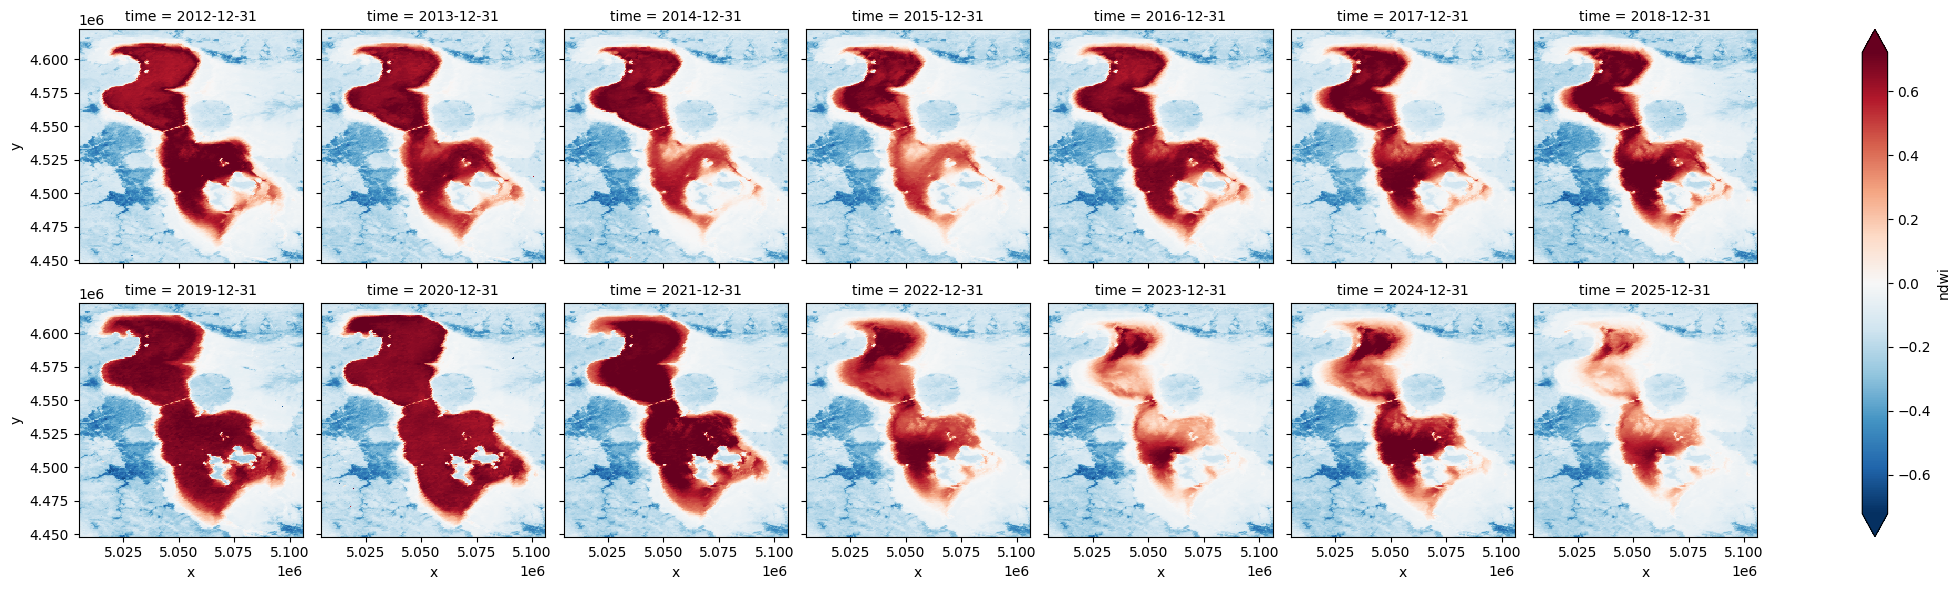

In [ ]:
ds_annual.ndwi.plot(
    robust =True, col = 'time', col_wrap = 7
)

In [ ]:
ds_diff = ds_annual.diff('time')

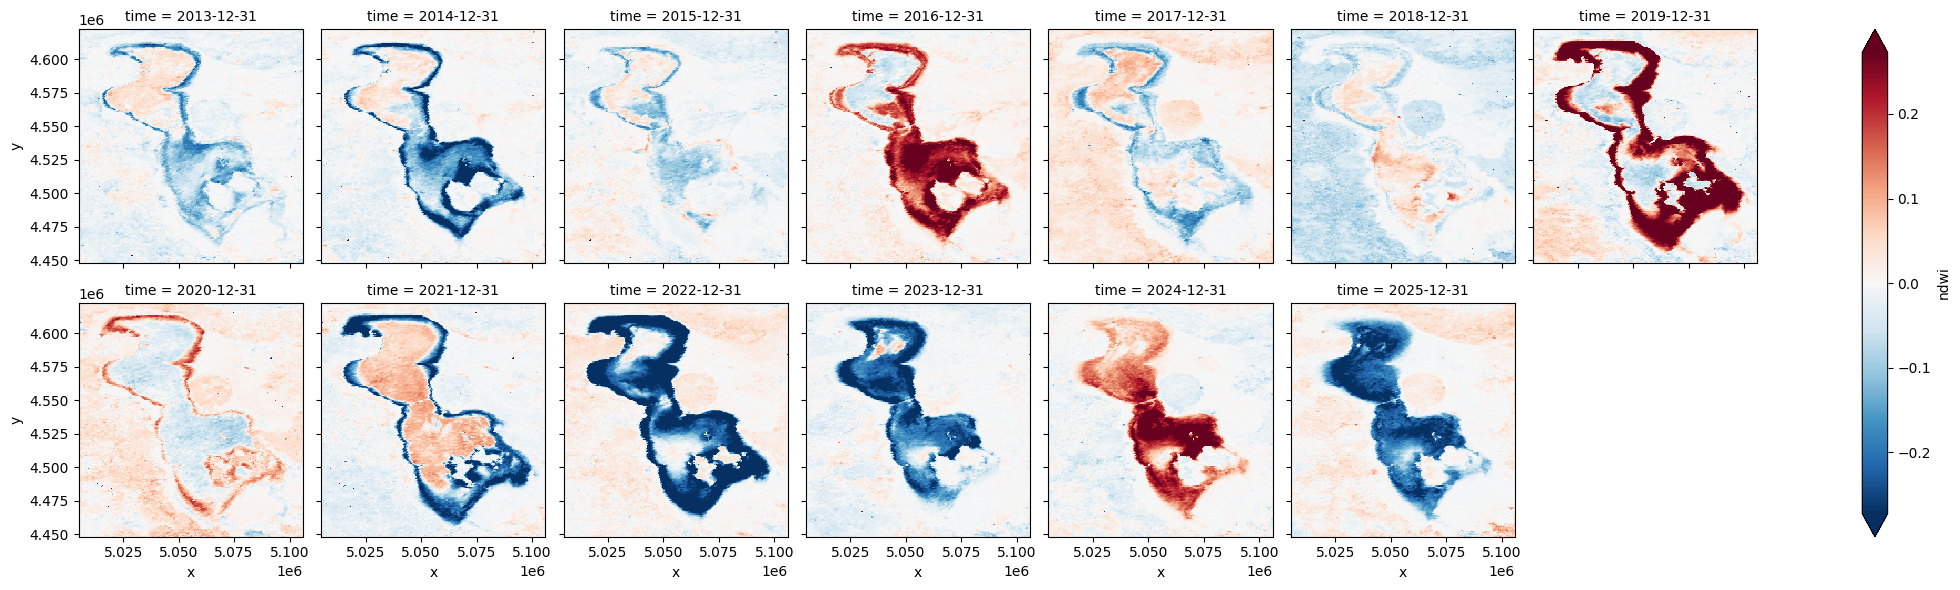

In [ ]:
ds_diff.ndwi.plot(
    robust =True, col = 'time', col_wrap =  7
)

In [ ]:
ds_anomaly = ds_annual - ds_annual.mean('time')

In [ ]:
import matplotlib.pyplot as plt

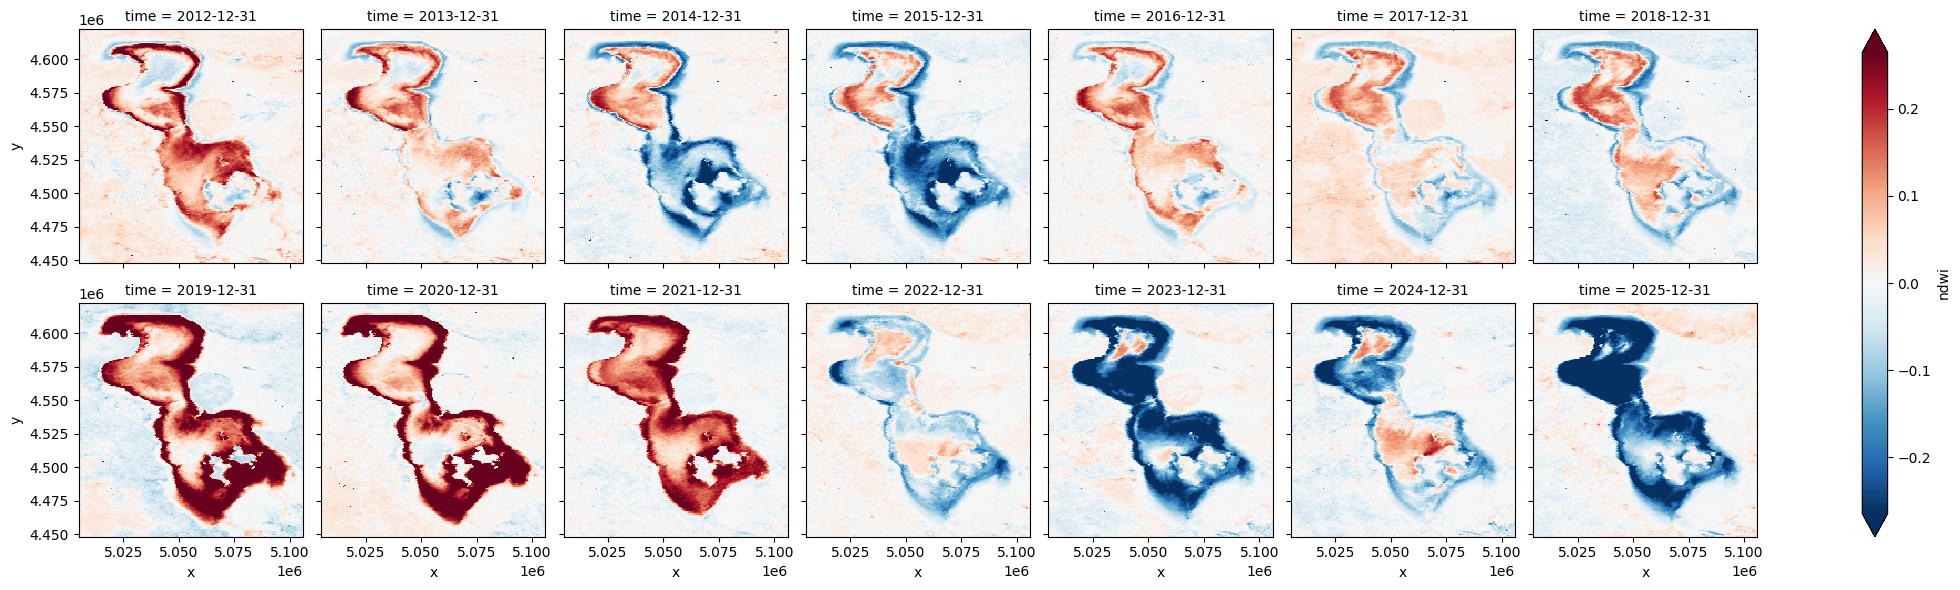

In [ ]:
ds_anomaly.ndwi.plot(
    robust = True, col = 'time', col_wrap = 7
)

plt.savefig('ndwi_anomaly.png', dpi = 360, bbox_inches = 'tight')

# **Lake Area**

In [ ]:
from skimage.filters import threshold_otsu

In [ ]:
dates= ds_interp.time.values

In [ ]:
output = []

for i in dates:
  img = ds_interp.sel(time = i).ndwi.values
  thr = threshold_otsu(img)
  output.append(thr)


In [ ]:
thr_xr = xr.DataArray(
    output,
    dims = ['time'],
    coords = {'time': dates}
)

In [ ]:
water_body = (ds_interp >= thr_xr).astype(int)

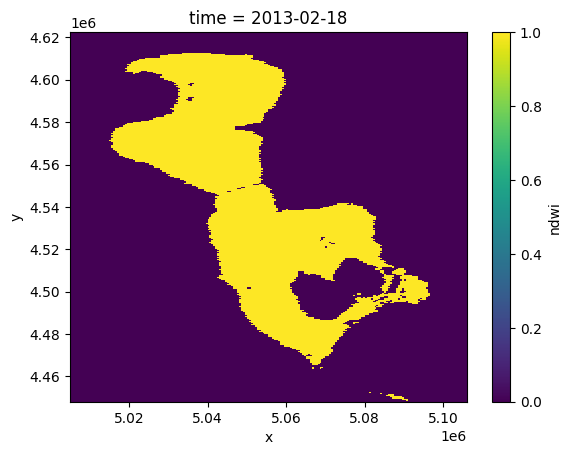

In [ ]:
water_body.isel(time = 50).ndwi.plot()

In [ ]:
water_pixels = (water_body == 1).astype(int).sum(dim = ['x','y'])

In [ ]:
water_area = (water_pixels * (500 * 500)) / 1e6

In [ ]:
df = water_area.to_dataframe()

In [ ]:
thr2 = df.mean() + df.std()
thr2

,0
ndwi,5983.737065


In [ ]:
df_clean = df[df <= thr2]

In [ ]:
df_clean.to_csv('lake_area.csv')

<Axes: xlabel='time'>

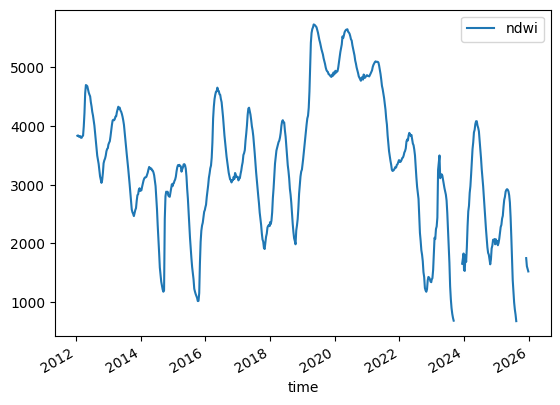

In [ ]:
df_clean.plot()